# Аудит неопределённости сопровождения

Читает только сохранённые результаты 48 треков. Проверка SHA исходных и производных файлов выполняется до визуализации. Все сравнительные значения ниже описательные: последовательные эпохи одного потока коррелированы. Truth используется только при offline проверке и графиках, не при вычислении диагностического статуса.

In [1]:
from pathlib import Path
import os, sys
project = Path.cwd()
if not (project / 'results').exists():
    project = project.parent
os.chdir(project)
sys.path.insert(0, str(project))
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from analysis.tracking_uncertainty_quality import verify

out = Path('results/tracking_uncertainty_quality')
assert verify(out)['status'] == 'verified'
read = lambda name: pd.read_csv(out / name)
method = read('method_comparison.csv')
cost = read('cost_by_method.csv')
quality = read('nominal_quality.csv')
transition = read('coverage_transition_summary.csv')
print('48 исходных треков; 0 replay; 0 новых аудиосинтезов')
display(cost[['estimator_variant','confirmation_variant','total_executed_optimizations','sum_final_generation_optimizations','maximum_single_generation_optimizations','attempts_rejected_before_optimization']])

48 исходных треков; 0 replay; 0 новых аудиосинтезов


,estimator_variant,confirmation_variant,total_executed_optimizations,sum_final_generation_optimizations,maximum_single_generation_optimizations,attempts_rejected_before_optimization
0,all_6_equal_gcc_wls,baseline,633,568,128,3
1,all_6_equal_gcc_wls,three_station_confirmation,690,625,128,3
2,equal_weight_srp_phat,baseline,379,263,47,0
3,equal_weight_srp_phat,three_station_confirmation,467,422,81,0


## Собственные и общие временные метки

`own_valid` использует все валидные публикации каждого варианта; `shared_valid` — пересечение временных меток с валидной оценкой у обоих. Покрытие определяется квадратичной формой $e_q^T P_{qq}^{-1} e_q\leq\chi^2_{3,0.95}$, а не сравнением длины ошибки с максимальной полуосью.

,estimator_variant,confirmation_variant,basis,valid_count,position_coverage,position_error_median_m,velocity_error_median_mps,position_max_axis_median_m,position_nees_median
0,all_6_equal_gcc_wls,baseline,own_valid,1126,0.745115,2.683388,2.416649,12.383861,2.822647
1,all_6_equal_gcc_wls,baseline,shared_valid,1097,0.743847,2.386437,2.345864,6.590749,2.658754
2,all_6_equal_gcc_wls,three_station_confirmation,own_valid,1097,0.688241,2.386437,2.286884,6.590749,2.498384
3,all_6_equal_gcc_wls,three_station_confirmation,shared_valid,1097,0.688241,2.386437,2.286884,6.590749,2.498384
4,equal_weight_srp_phat,baseline,own_valid,1470,0.697279,22.547124,4.629969,37.901033,4.024750
5,equal_weight_srp_phat,baseline,shared_valid,1344,0.697173,14.691269,3.113694,35.406730,3.455073
6,equal_weight_srp_phat,three_station_confirmation,own_valid,1413,0.541401,19.000376,3.425042,35.889754,4.129818
7,equal_weight_srp_phat,three_station_confirmation,shared_valid,1344,0.559524,14.443079,3.015405,35.037292,3.427771


,estimator_variant,shared_valid_count,coverage_lost_count,coverage_gained_count,lost_with_larger_position_error_count,lost_with_smaller_max_axis_count,lost_where_new_covariance_alone_would_exclude_baseline_error_count
0,all_6_equal_gcc_wls,1097,61,0,1,61,60
4,equal_weight_srp_phat,1344,203,18,6,197,197


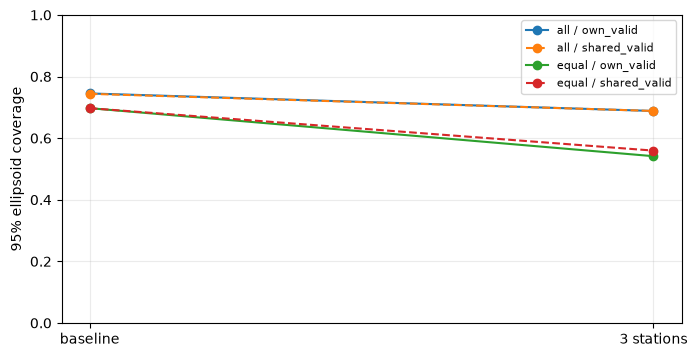

In [2]:
display(method[['estimator_variant','confirmation_variant','basis','valid_count','position_coverage','position_error_median_m','velocity_error_median_mps','position_max_axis_median_m','position_nees_median']])
selected = transition[transition.phase.eq('all_shared')]
display(selected[['estimator_variant','shared_valid_count','coverage_lost_count','coverage_gained_count','lost_with_larger_position_error_count','lost_with_smaller_max_axis_count','lost_where_new_covariance_alone_would_exclude_baseline_error_count']])
fig, ax = plt.subplots(figsize=(8,4))
for method_name, rows in method.groupby('estimator_variant'):
    for basis, style in [('own_valid','-'),('shared_valid','--')]:
        piece = rows[rows.basis.eq(basis)].set_index('confirmation_variant')
        ax.plot([0,1], [piece.loc['baseline','position_coverage'],piece.loc['three_station_confirmation','position_coverage']], style, marker='o', label=f'{method_name.split("_")[0]} / {basis}')
ax.set_xticks([0,1],['baseline','3 stations']); ax.set_ylabel('95% ellipsoid coverage')
ax.set_ylim(0,1); ax.grid(True, alpha=.25); ax.legend(fontsize=8); plt.show()

## Фазы, возраст трека и пример потери покрытия

График показывает один сохранённый поток с большим числом переходов `covered → uncovered`. Ошибка и полуось представлены отдельно; покрытие вычисляется по всей ковариации. Это наблюдение не является доказательством причины изменения ковариации.

,estimator_variant,confirmation_variant,phase,valid_count,position_coverage,position_error_median_m,velocity_error_median_mps,position_max_axis_median_m,position_nees_median,time_since_last_update_median_s,accepted_update_count,rejected_update_count
0,all_6_equal_gcc_wls,baseline,first_confirmation,9,0.666667,62.516357,17.079756,68.900328,3.704742,NaN,0,0
1,all_6_equal_gcc_wls,baseline,subsequent_tracking,1080,0.771296,2.353277,2.326241,6.466318,2.610729,0.000000,741,339
2,all_6_equal_gcc_wls,baseline,after_reset,37,0.000000,106.780552,14.666596,64.967770,44.475162,0.326333,11,25
5,all_6_equal_gcc_wls,three_station_confirmation,first_confirmation,9,0.555556,27.226996,8.861211,68.706395,3.704742,NaN,0,0
6,all_6_equal_gcc_wls,three_station_confirmation,subsequent_tracking,1053,0.712251,2.201311,2.230387,6.347969,2.365139,0.000000,816,237
7,all_6_equal_gcc_wls,three_station_confirmation,after_reset,35,0.000000,120.922536,17.877108,56.392180,51.688919,5.120000,9,25
10,equal_weight_srp_phat,baseline,first_confirmation,12,0.583333,104.970785,21.695431,122.601178,5.723103,NaN,0,0
11,equal_weight_srp_phat,baseline,subsequent_tracking,1269,0.706856,11.459314,2.862884,34.399336,3.354040,0.000000,754,515
12,equal_weight_srp_phat,baseline,after_reset,189,0.640212,1746.254524,225.462099,3680.115102,6.833537,6.159000,13,172
15,equal_weight_srp_phat,three_station_confirmation,first_confirmation,12,0.416667,69.906394,15.874654,71.510798,10.395509,NaN,0,0


,estimator_variant,confirmation_variant,reset_group,track_age_band,valid_count,position_coverage,position_error_median_m,position_max_axis_median_m
0,all_6_equal_gcc_wls,baseline,before_reset,0_to_1s,79,0.670886,70.139525,74.572563
1,all_6_equal_gcc_wls,baseline,before_reset,1_to_3s,161,0.652174,87.686365,61.388573
2,all_6_equal_gcc_wls,baseline,before_reset,3s_plus,849,0.802120,2.222240,6.163279
3,all_6_equal_gcc_wls,baseline,after_reset,0_to_1s,8,0.000000,93.492492,67.449613
4,all_6_equal_gcc_wls,baseline,after_reset,1_to_3s,17,0.000000,116.204834,74.325984
5,all_6_equal_gcc_wls,baseline,after_reset,3s_plus,12,0.000000,97.894578,42.327724
6,all_6_equal_gcc_wls,three_station_confirmation,before_reset,0_to_1s,79,0.569620,30.229868,69.148832
7,all_6_equal_gcc_wls,three_station_confirmation,before_reset,1_to_3s,161,0.546584,40.757775,61.388573
8,all_6_equal_gcc_wls,three_station_confirmation,before_reset,3s_plus,822,0.756691,2.132788,6.090438
9,all_6_equal_gcc_wls,three_station_confirmation,after_reset,0_to_1s,8,0.000000,120.728831,56.031360


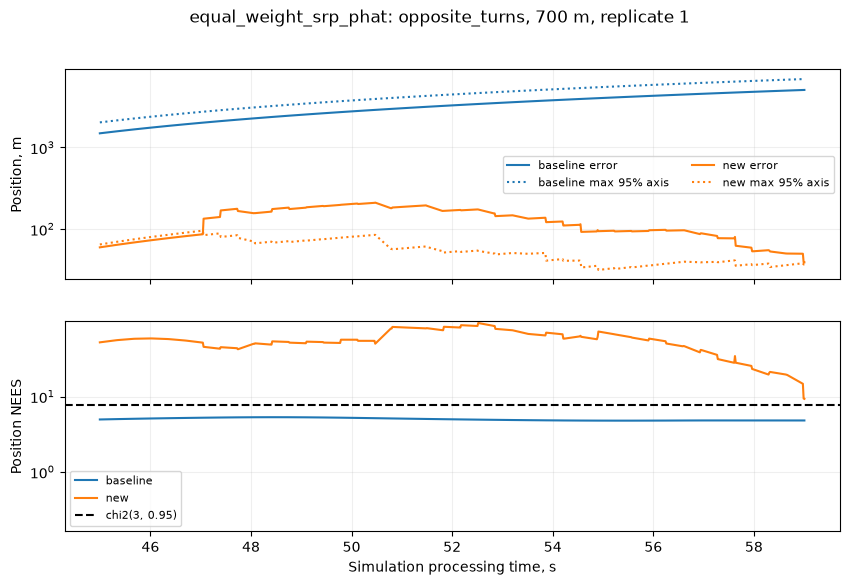

In [3]:
phase = read('phase_summary.csv')
age = read('age_summary.csv')
by_stream = read('coverage_transition_by_stream.csv')
display(phase[phase.phase.isin(['first_confirmation','subsequent_tracking','after_reset'])][['estimator_variant','confirmation_variant','phase','valid_count','position_coverage','position_error_median_m','velocity_error_median_mps','position_max_axis_median_m','position_nees_median','time_since_last_update_median_s','accepted_update_count','rejected_update_count']])
display(age[['estimator_variant','confirmation_variant','reset_group','track_age_band','valid_count','position_coverage','position_error_median_m','position_max_axis_median_m']])
case = by_stream.sort_values('coverage_lost_count',ascending=False).iloc[0]
epoch = read('coverage_transition_epoch.csv.gz')
subset = epoch[(epoch.run_id == case.run_id) & (epoch.estimator_variant == case.estimator_variant)]
fig, axes = plt.subplots(2,1,figsize=(10,6),sharex=True)
for variant,color in [('baseline','tab:blue'),('new','tab:orange')]:
    axes[0].plot(subset.processing_time_s,subset[f'{variant}_position_error_m'],label=f'{variant} error',color=color)
    axes[0].plot(subset.processing_time_s,subset[f'{variant}_max_axis_m'],ls=':',label=f'{variant} max 95% axis',color=color)
    axes[1].plot(subset.processing_time_s,subset[f'{variant}_position_nees'],label=variant,color=color)
axes[0].set_yscale('symlog',linthresh=1); axes[0].set_ylabel('Position, m'); axes[0].legend(ncol=2,fontsize=8)
axes[1].axhline(7.814727903251179,ls='--',color='black',label='chi2(3, 0.95)'); axes[1].set_yscale('symlog',linthresh=1); axes[1].set_ylabel('Position NEES'); axes[1].set_xlabel('Simulation processing time, s'); axes[1].legend(fontsize=8)
for ax in axes: ax.grid(True,alpha=.2)
fig.suptitle(f'{case.estimator_variant}: {case.trajectory}, {case.distance_m} m, replicate {case.replicate}'); plt.show()

## Номинальная точность координат

Диагностический признак получает только опубликованные координаты, статус и $P_{qq}$. Для допусков 2, 5 и 10 м он сравнивает $a_{max}=\sqrt{\chi^2_{3,0.95}\lambda_{max}(P_{qq})}$ с допуском. Условная фактическая ошибка ниже вычислена отдельно с truth; нулевой знаменатель показан как NaN.

In [4]:
display(quality[quality.distance_m.eq('all')][['estimator_variant','confirmation_variant','tolerance_m','all_publications','unavailable_count','nominal_precision_within_target_count','nominal_within_fraction_all','conditional_position_error_median_m','conditional_position_error_p95_m','false_precision_count','false_precision_fraction_conditional']])
display(quality[(quality.tolerance_m.eq(5)) & (quality.distance_m.ne('all'))][['estimator_variant','confirmation_variant','distance_m','all_publications','nominal_precision_within_target_count','false_precision_fraction_conditional']])

,estimator_variant,confirmation_variant,tolerance_m,all_publications,unavailable_count,nominal_precision_within_target_count,nominal_within_fraction_all,conditional_position_error_median_m,conditional_position_error_p95_m,false_precision_count,false_precision_fraction_conditional
0,all_6_equal_gcc_wls,baseline,2.0,1872,746,0,0.000000,NaN,NaN,0,NaN
1,all_6_equal_gcc_wls,baseline,5.0,1872,746,123,0.065705,0.891257,2.006072,0,0.0
2,all_6_equal_gcc_wls,baseline,10.0,1872,746,556,0.297009,1.155340,2.612591,0,0.0
12,all_6_equal_gcc_wls,three_station_confirmation,2.0,1872,775,0,0.000000,NaN,NaN,0,NaN
13,all_6_equal_gcc_wls,three_station_confirmation,5.0,1872,775,123,0.065705,0.891257,2.006072,0,0.0
14,all_6_equal_gcc_wls,three_station_confirmation,10.0,1872,775,556,0.297009,1.155340,2.612591,0,0.0
24,equal_weight_srp_phat,baseline,2.0,1872,402,0,0.000000,NaN,NaN,0,NaN
25,equal_weight_srp_phat,baseline,5.0,1872,402,125,0.066774,0.903142,2.100559,0,0.0
26,equal_weight_srp_phat,baseline,10.0,1872,402,556,0.297009,1.150825,2.629140,0,0.0
36,equal_weight_srp_phat,three_station_confirmation,2.0,1872,459,0,0.000000,NaN,NaN,0,NaN


,estimator_variant,confirmation_variant,distance_m,all_publications,nominal_precision_within_target_count,false_precision_fraction_conditional
4,all_6_equal_gcc_wls,baseline,200,624,123,0.0
7,all_6_equal_gcc_wls,baseline,700,624,0,NaN
10,all_6_equal_gcc_wls,baseline,1000,624,0,NaN
16,all_6_equal_gcc_wls,three_station_confirmation,200,624,123,0.0
19,all_6_equal_gcc_wls,three_station_confirmation,700,624,0,NaN
22,all_6_equal_gcc_wls,three_station_confirmation,1000,624,0,NaN
28,equal_weight_srp_phat,baseline,200,624,125,0.0
31,equal_weight_srp_phat,baseline,700,624,0,NaN
34,equal_weight_srp_phat,baseline,1000,624,0,NaN
40,equal_weight_srp_phat,three_station_confirmation,200,624,125,0.0
